In [1]:
from InterOptimus.itworker import InterfaceWorker
from pymatgen.core.structure import Structure
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Define InterfaceWorker

In [2]:
film_conv = Structure.from_file('film.cif')
substrate_conv = Structure.from_file('substrate.cif')
iw = InterfaceWorker(film_conv, substrate_conv)

/Users/jason/Downloads/pymatgen-master/src/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


# lattice matching

In [3]:
iw.lattice_matching(max_area = 30, max_length_tol = 0.03, max_angle_tol = 0.03,
                    film_max_miller = 1, substrate_max_miller = 1, film_millers = None, substrate_millers = None)
#Note max millers are in primitive cell, should be different from the indices in the polar projection below which are in conventional cell
#If you specify miller indices yourself, just ignore film_max_miller and substrate_max_miller

5


checking matching identity:   0%|          | 0/5 [00:00<?, ?it/s]

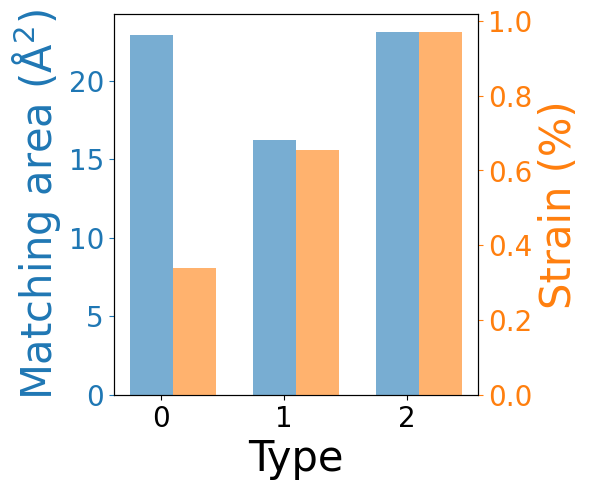

In [4]:
#Visualize matching information
iw.ems.plot_unique_matches()

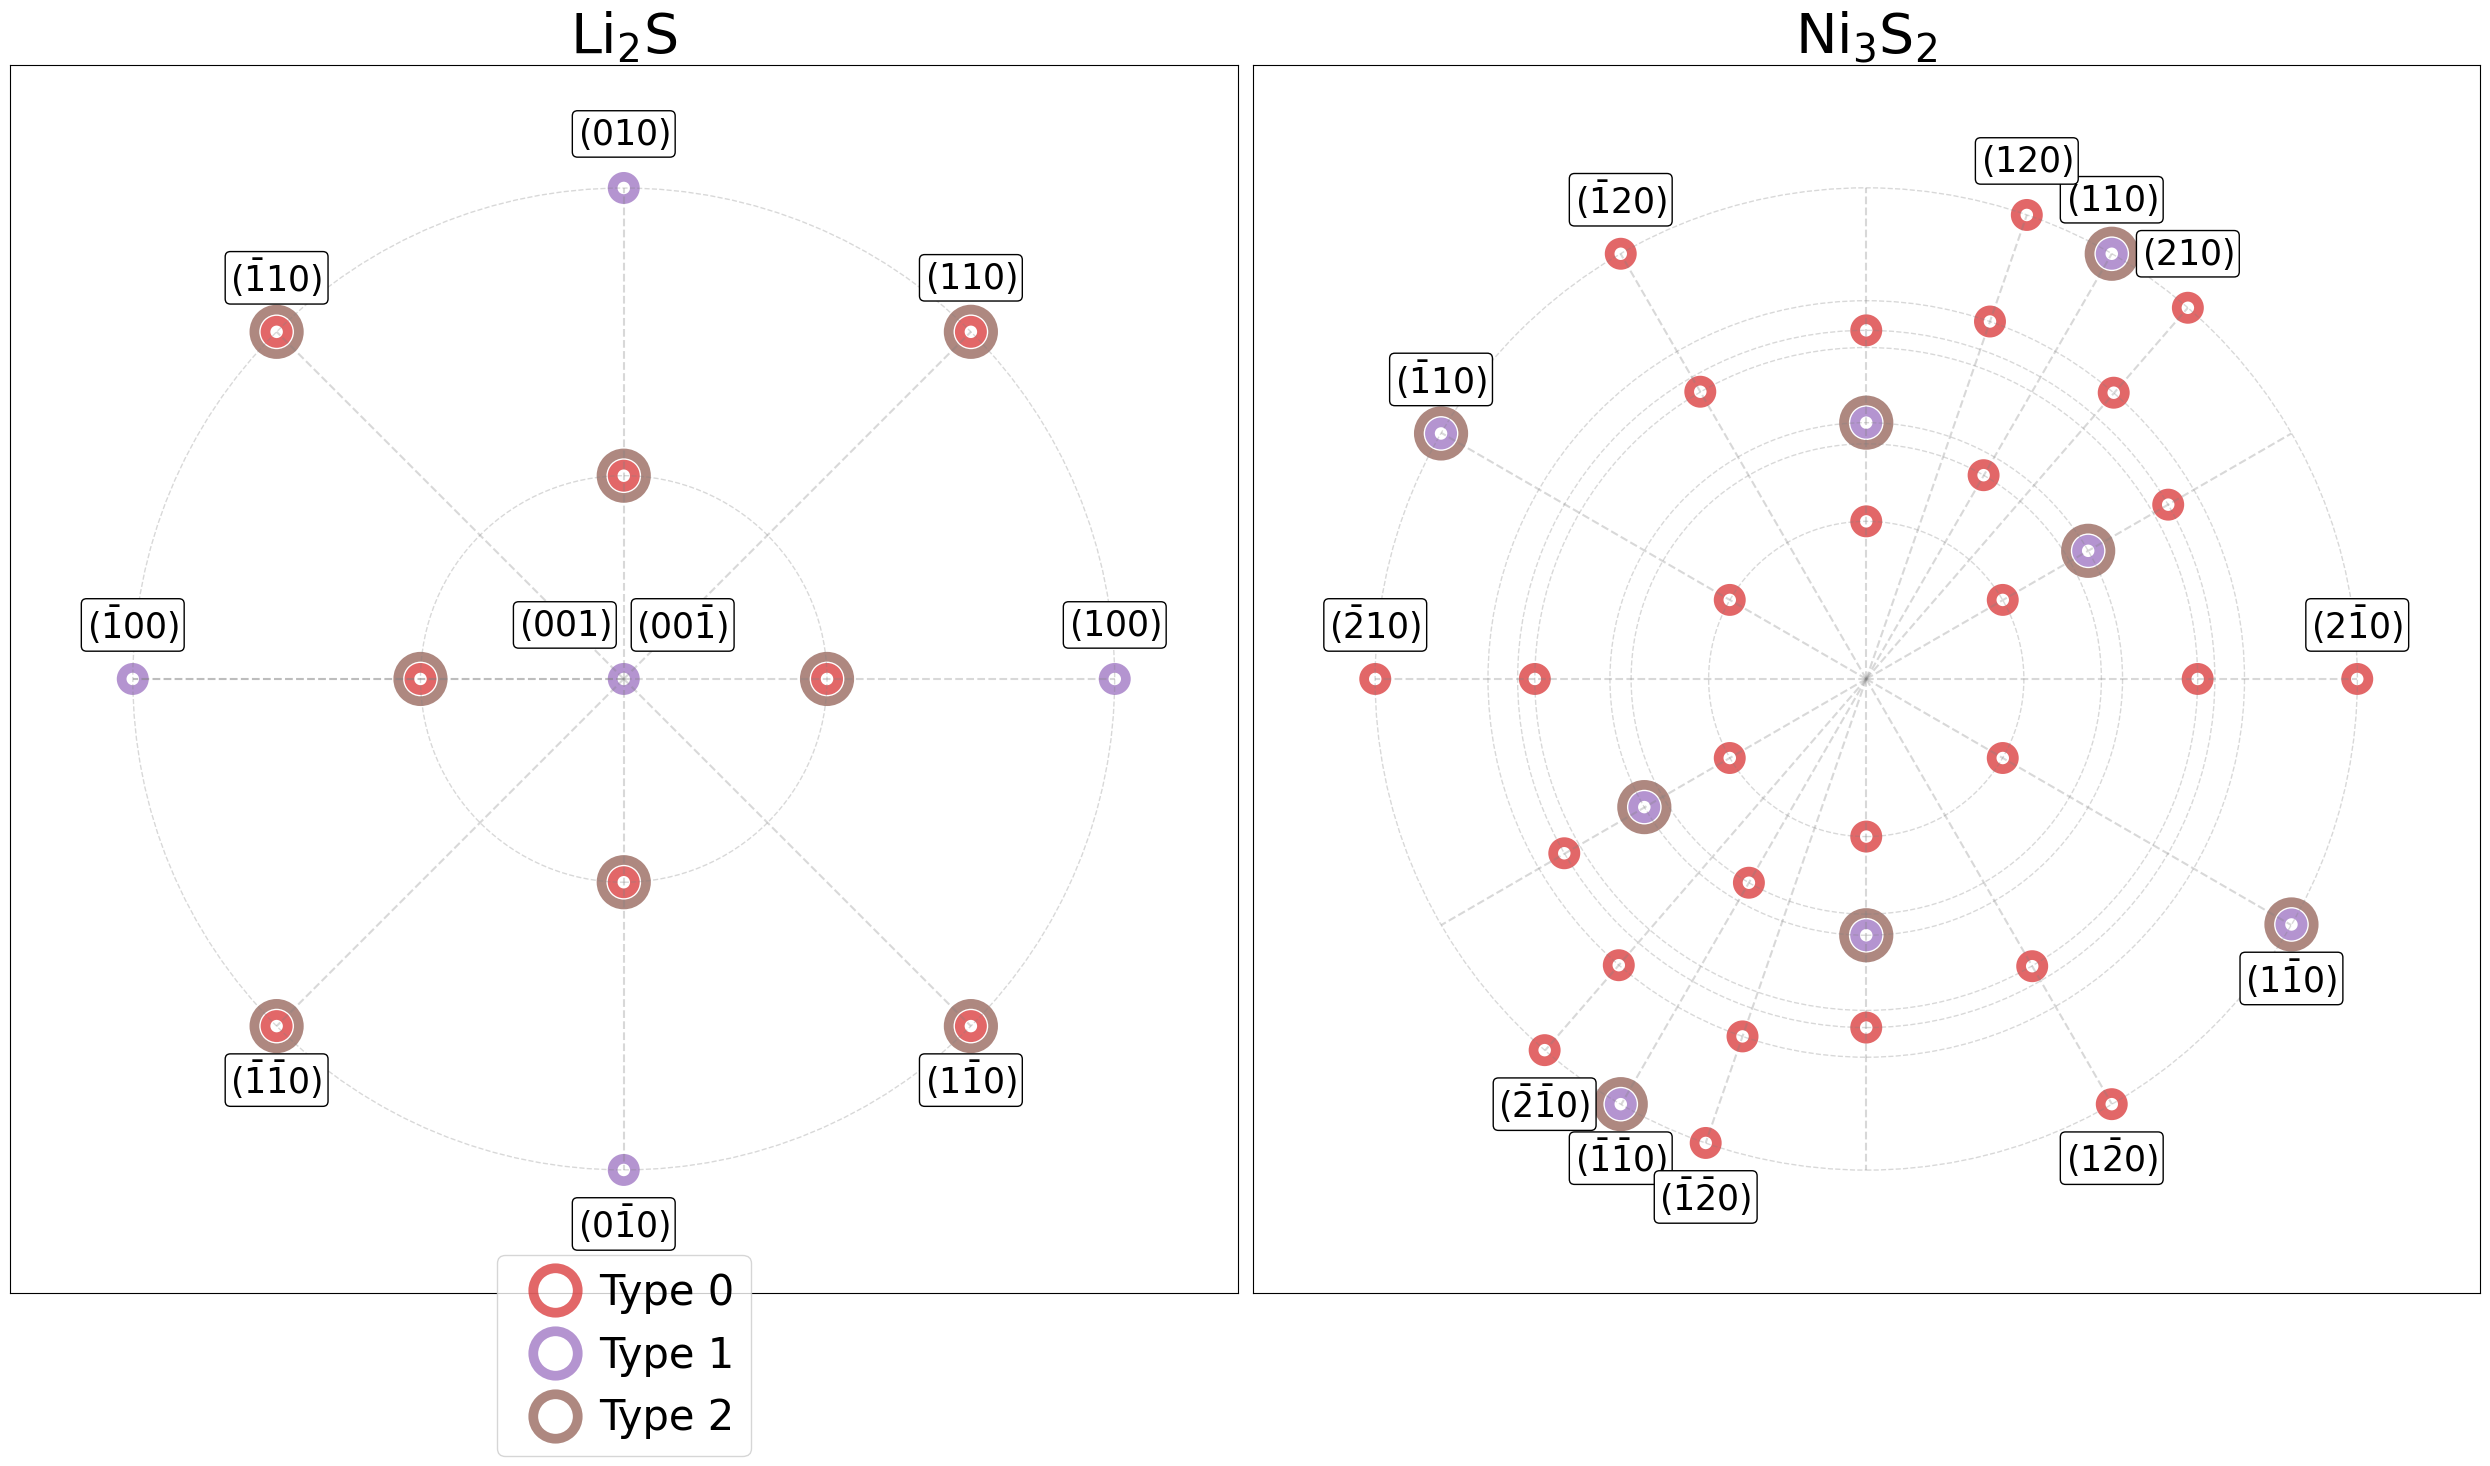

In [5]:
iw.ems.plot_matching_data(['Li$_2$S', 'Ni$_3$S$_2$'],'Ni3S2_Li2S_more.jpg', show_millers = True, show_legend = True)

# Define interface structural parameters 

For usage presentation, a large **termination_ftol** value is applied there.  
However, for some complex systems, a small enough **termination_ftol** (e.g. 0.01) is necessary to find stable interface structures.

In [6]:
#These are defualt settings
iw.parse_interface_structure_params(termination_ftol = 0.15, film_thickness = 15, \
                                    substrate_thickness = 15, double_interface= False,
                                   vacuum_over_film=5)



match 0: thicknesses (film, substrate) (2.0, 2.86) (7, 5) (14.03 14.32)
match 1: thicknesses (film, substrate) (2.84, 4.03) (5, 4) (14.18 16.12)
match 2: thicknesses (film, substrate) (2.0, 2.84) (7, 5) (14.03 14.18)
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 0: number of unique terminations: 4
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 1: number of unique terminations: 6
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 2: number of unique terminations: 3


# Baysian Optimization by MLIP for Rigid Body Translation (RBT)

In [20]:
#define structure optimization conditions (optional). If not called, the non-optimized energy and structure will be used
iw.parse_optimization_params(set_relax_thicknesses = (4,4),
                             relax_in_layers = False,
                             fmax = 0.05,
                             steps = 200,
                             device = 'cpu',
                             discut = 0.8,
                             ckpt_path = 'orb-v3-conservative-20-omat-20250404.ckpt',
                             BO_coord_bin_size = 0.25,
                             BO_energy_bin_size = 0.5,
                             BO_rms_bin_size = 0.3)

match 0: fix/slab thicknesses (film, substrate) (10.03/14.03, 10.32/14.32)
match 1: fix/slab thicknesses (film, substrate) (10.18/14.18, 12.12/16.12)
match 2: fix/slab thicknesses (film, substrate) (10.03/14.03, 10.18/14.18)


**set_relax_thicknesses**: thickness for relaxing  
**relax_in_layers**: whether to set relaxing thickness in layers  
**fmax**: tolerance to stop structure optimization  
**steps**: maximum relaxing steps  
**device**: device to use for MLIP  
**ckpt_path**: path to store the check point, downloading if not set  
**discut**: those with atoyms closer than discut will have energy as 0 (ignore these structures)  

In [21]:
iw.global_minimization(n_calls_density = 1, 
                       z_range = (0.5, 3),
                       calc = 'orb-models', 
                       strain_E_correction = True)

cpu


/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/orb_models/utils.py:30: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")


matches:   0%|          | 0/3 [00:00<?, ?it/s]

unique terminations:   0%|          | 0/4 [00:00<?, ?it/s]

registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

...

registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

num of selected low-energy its: 6


registration optimizing:   0%|          | 0/22 [00:00<?, ?it/s]

num of selected low-energy its: 3


KeyboardInterrupt: 

**n_calls**: number of bayesian optimization for each RBT optimizatio  
**z_range**: range of z coordinates for RBT optimization  
**calc**: energy calculator (only for orb-models and sevenn)  
**strain_E_correction**: whether the binding energy or interface energy is corrected considering film elastic energy by strain

In [22]:
from pymatgen.transformations.site_transformations import TranslateSitesTransformation

In [23]:
it = iw.opt_results[(0,1)]['relaxed_best_interface']['structure']

In [24]:
import numpy as np

In [25]:
from numpy import inf, zeros, dot
from numpy.linalg import norm

In [26]:
def gradient_descend(sampling_function, dx, dim, tol, initial_r, initial_xy, min_steps, **kwargs):
    dy = inf
    g_n = zeros(dim)
    xs = []
    ys = []
    rs = []
    if initial_xy is not None:
        x_n, y_n = initial_xy
        xs.append(x_n)
        ys.append(y_n)
        rs.append(0)
    else:
        x_n = zeros(dim)
        y_n = test_func(x_n)
    
    count = 0
    while abs(dy) > tol or count < min_steps:
        g_n_1 = g_n.copy()
        for i in range(dim):
            pdx = zeros(dim)
            pdx[i] = dx
            g_n[i] = (sampling_function(x_n + pdx, **kwargs) - y_n) / dx
        
        if count == 0:
            r = initial_r
        else:
            r = abs(dot((x_n - x_n_1), (g_n - g_n_1))) / norm(g_n - g_n_1) ** 2
        print(x_n, y_n)
        x_n_1, y_n_1 = x_n.copy(), y_n
        x_n += - r * g_n
        y_n = sampling_function(x_n, **kwargs)
        dy = y_n - y_n_1
        xs.append(x_n.copy())
        ys.append(y_n)
        rs.append(r)
        count += 1
    
    return xs, ys, rs

In [39]:
it.to_file('o_POSCAR')
iw.gradient_descend_interface.to_file('d_POSCAR')

'Li14 Ni15 S17\n1.0\n   4.0309644416534960    0.0000000000000000    0.0000000000000002\n   0.0000000000000022    5.6738238499999998    0.0000000000000003\n   0.0000000000000000    0.0000000000000000   32.3257793936507056\nLi Ni S\n14 15 17\nSelective dynamics\ndirect\n   0.7348465123073163    0.3558348832450366    0.8439358317877211 F F F Li\n   0.7351713101725222    0.9126261106597892    0.8439459133475796 F F F Li\n   0.2350222745164090    0.8862822346068059    0.7849477134104340 F F F Li\n   0.2349983140578482    0.3822276008598336    0.7849446222937458 F F F Li\n   0.7349649168943252    0.3839746290415501    0.7225454810374777 F F F Li\n   0.7349895037763601    0.8845444614220775    0.7225360014694687 F F F Li\n   0.2349435880204094    0.8837970247078023    0.6600471884211822 F F F Li\n   0.2349644290446171    0.3848175034886555    0.6600516592371427 F F F Li\n   0.7362947567736756    0.3845365282718124    0.5983317332155528 F F F Li\n   0.7364169351881633    0.8860585298676140    

In [28]:
gradient_descend(sampling_function = iw.get_displaced_relaxed_interface, 
                 dx = 0.01, 
                 dim = 3, 
                 tol = 5e-05 * len(it),
                 initial_r = 0.1,
                 initial_xy = [np.array([0.0,0.0,0.0]), iw.opt_results[(0,1)]['relaxed_best_interface']['e']],
                 min_steps = 5,
                interface = it)

[0. 0. 0.] -212.86109924316406
[-0.00579834 -0.00183105  0.02380371] -212.8634490966797
[-0.00833034 -0.0024098   0.01121606] -212.8639373779297
[-0.00945079 -0.00247419  0.01021151] -212.8618621826172
[-0.00903331 -0.00196219  0.01015637] -212.86183166503906


([array([-0.00881846, -0.00198043,  0.01041176]),
  array([-0.00579834, -0.00183105,  0.02380371]),
  array([-0.00833034, -0.0024098 ,  0.01121606]),
  array([-0.00945079, -0.00247419,  0.01021151]),
  array([-0.00903331, -0.00196219,  0.01015637]),
  array([-0.00881846, -0.00198043,  0.01041176])],
 [-212.86109924316406,
  -212.8634490966797,
  -212.8639373779297,
  -212.8618621826172,
  -212.86183166503906,
  -212.8639373779297],
 [0,
  0.1,
  0.047410603626348406,
  0.004220120400146746,
  0.0025811291218933506,
  0.0013283321680204482])

In [9]:
iw.global_optimized_data

,$h_f$,$k_f$,$l_f$,$h_s$,$k_s$,$l_s$,$A$ (Å$^2$),$\epsilon$,$E_{bd}$ $(J/m^2)$,$E_{el}$ $(eV/atom)$,...,$w_{f2}$,$u_{s1}$,$v_{s1}$,$w_{s1}$,$u_{s2}$,$v_{s2}$,$w_{s2}$,$T$,$i_m$,$i_t$
1,-1,0,1,1,-1,2,22.870982,0.003387,-0.650997,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 2_Ni_Pmmm_1)",0,1
0,-1,0,1,1,-1,2,22.870982,0.003387,-0.589133,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 1_Ni_Pmmm_1)",0,0
3,-1,0,1,1,-1,2,22.870982,0.003387,-0.406871,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 4_Ni_Pmmm_1)",0,3
2,-1,0,1,1,-1,2,22.870982,0.003387,-0.191697,-0.000196,...,0,-1/3,1/3,1/3,1,1,0,"(1_Li2S_Pmmm_3, 3_S_Pmmn_2)",0,2


# Get the interface with lowest predicted energy by MLIP for each match

In [19]:
iw.global_optimized_data.to_csv('all_data.csv')

In [20]:
import shutil
import os
try:
    shutil.rmtree('it_and_slab_structures')
except:
    pass
os.mkdir('it_and_slab_structures')

In [21]:
#Output lowest-it-energy interfaces for each lattice matching type
ids = iw.global_optimized_data.index.to_numpy()
i_s = iw.global_optimized_data['$i_m$'].to_numpy()
j_s = iw.global_optimized_data['$i_t$'].to_numpy()

match_ids = []
pairs = []
for i in range(len(i_s)):
    if i_s[i] not in match_ids:
        match_ids.append(i_s[i])
        pairs.append((i_s[i], j_s[i]))

for i in range(len(ids)):
    iw.opt_results[(i_s[i],j_s[i])]['relaxed_best_interface']['structure'].to_file(f'it_and_slab_structures/{ids[i]}_it_POSCAR')
    iw.opt_results[(i_s[i],j_s[i])]['slabs']['film']['structure'].to_file(f'it_and_slab_structures/{ids[i]}_film_POSCAR')
    iw.opt_results[(i_s[i],j_s[i])]['slabs']['substrate']['structure'].to_file(f'it_and_slab_structures/{ids[i]}_substrate_POSCAR')

In [22]:
lowest_it_each_match = {}

In [23]:
try:
    shutil.rmtree('lowest_it_each_match')
except:
    pass
os.mkdir('lowest_it_each_match')

In [24]:
types = []
it_Es = []
for i in pairs:
    lowest_it_each_match[i[0]] = {}
    lowest_it_each_match[i[0]]['A'] = iw.opt_results[i]['A']
    lowest_it_each_match[i[0]]['bd_E'] = iw.opt_results[i]['relaxed_min_bd_E']
    types.append(i[0])
    it_Es.append(lowest_it_each_match[i[0]]['bd_E'])
    iw.opt_results[i]['relaxed_best_interface']['structure'].to_file(f'lowest_it_each_match/{i[0]}_it_POSCAR')

In [25]:
import numpy as np

In [26]:
np.savetxt('bd_Es.dat',np.column_stack((types, it_Es)), fmt = '%i %.4f')